In [12]:
import pandas as pd
import numpy as np
from skbio.stats.composition import clr, multiplicative_replacement
from scipy.spatial.distance import euclidean

In [13]:
def aitchison_distance_between_datasets(df_orig, df_syn, cell_types):
    data_orig = df_orig[cell_types].values.astype(float)
    data_syn = df_syn[cell_types].values.astype(float)

    # 2. Xử lý số 0 cho ma trận (multiplicative_replacement hoạt động tốt trên 2D)
    data_orig_filled = multiplicative_replacement(data_orig)
    data_syn_filled = multiplicative_replacement(data_syn)

    # 3. Tính Trung tâm (Geometric Mean) cho từng cột
    # Kết quả trả về là vector 1D (k thành phần)
    center_orig = np.exp(np.mean(np.log(data_orig_filled), axis=0))
    center_syn = np.exp(np.mean(np.log(data_syn_filled), axis=0))

    
    
    # 4. Biến đổi CLR
    # Thủ thuật: skbio clr đôi khi yêu cầu input 2D. 
    # Ta reshape về (1, k), tính CLR, sau đó flatten về 1D.
    clr_orig = clr(center_orig.reshape(1, -1)).flatten()
    clr_syn = clr(center_syn.reshape(1, -1)).flatten()

    # 5. Tính khoảng cách Euclidean
    return euclidean(clr_orig, clr_syn)

In [19]:
seeds = [0, 1, 2, 3, 42]
ori_data = 'Origin'
or_res = pd.read_csv(f'ResultsCibersortx/CIBERSORTx_{ori_data}_Results.csv', index_col=0)
ori_cell = or_res.iloc[:, 0:22]
k = 10
top_k_cell = ori_cell.mean().sort_values(ascending=False).keys().tolist()[0:k]

Distance_Result = {}
Score_Result = {} # Thêm dict mới để lưu Score

for seed in seeds:
    datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', 
                f'gaussiancopula_{seed}', f'synthpop_{seed}', f'tvae_{seed}']
    names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
    
    res_as_seed_dist = {}
    res_as_seed_score = {}
    
    for i, dataset in enumerate(datasets):
        try:
            syn_res = pd.read_csv(f'ResultsCibersortx/CIBERSORTx_{dataset}_Results.csv', index_col=0)
            # Tính khoảng cách Aitchison
            distance = aitchison_distance_between_datasets(or_res, syn_res, top_k_cell)
            
            # Chuyển sang Score bằng hàm mũ âm: exp(-distance)
            # Distance càng nhỏ (gần 0) thì Score càng gần 1
            score = np.exp(-distance)
            
            res_as_seed_dist[names[i]] = distance
            res_as_seed_score[names[i]] = score
        except:
            continue

    Distance_Result[seed] = res_as_seed_dist
    Score_Result[seed] = res_as_seed_score

In [24]:


df = pd.DataFrame(Score_Result).T
df_long = df.melt(var_name='Tool', value_name='Score')

# 2. Tính Mean và STD, sau đó sắp xếp theo Mean tăng dần (tốt nhất đến kém nhất)
summary = df_long.groupby('Tool')['Score'].agg(['mean', 'std'])

# 3. Print kết quả
print(f"{'Tool Name':<20} | {'Mean (AitcsD)':<15} | {'Std Dev':<10}")
print("-" * 50)

for tool, stats in summary.iterrows():
    print(f"{tool:<20} | {stats['mean']:<15.3f}  {stats['std']:<10.3f}")

# 4. (Tùy chọn) Nếu bạn muốn copy vào báo cáo dạng bảng Markdown:
# print("\n" + summary.to_markdown())

Tool Name            | Mean (AitcsD)   | Std Dev   
--------------------------------------------------
Avatars K10          | 0.519            0.017     
Avatars K5           | 0.589            0.015     
CTGAN                | 0.229            0.041     
Gaussian Copula      | 0.515            0.057     
Synthpop             | 0.663            0.032     
TVAE                 | 0.410            0.101     


/tmp/ipykernel_1897440/2166811468.py:14: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


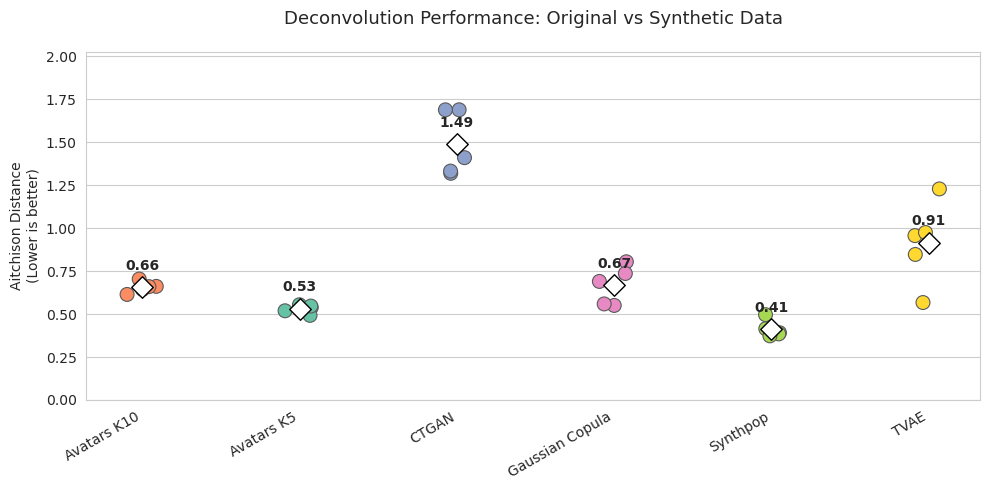

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuyển dữ liệu dict của bạn thành DataFrame long-format
df_long = pd.DataFrame(Distance_Result).T.melt(var_name='Method', value_name='Score')

# 2. Xác định thứ tự Method dựa trên điểm trung bình (Tăng dần)
method_order = df_long.groupby("Method")["Score"].mean().index

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

sns.stripplot(
    x='Method', 
    y='Score', 
    data=df_long, 
    order=method_order,
    size=10, 
    jitter=True, 
    palette='Set2', 
    edgecolor='gray', 
    linewidth=0.8,
    # alpha=0.6,
    hue='Method',
    legend=False
)

# Tính mean và vẽ diamond marker
means = df_long.groupby("Method")["Score"].mean().reindex(method_order)
offset = df_long['Score'].max() * 0.05 # Offset động dựa trên scale của dữ liệu

for i, mu in enumerate(means):
    plt.scatter(i, mu, marker='D', color='white', edgecolor='black', s=120, zorder=10)
    plt.text(i, mu + offset, f"{mu:.2f}", ha="center", va="bottom", fontsize=10, fontweight='bold')

plt.ylabel("Aitchison Distance\n(Lower is better)")
plt.xlabel("")
plt.xticks(rotation=30, ha='right')
plt.title("Deconvolution Performance: Original vs Synthetic Data", fontsize=13, pad=20)

# Giới hạn trục Y một chút để text label không bị cắt mất
plt.ylim(0, df_long['Score'].max() * 1.2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1897440/2599401681.py:11: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


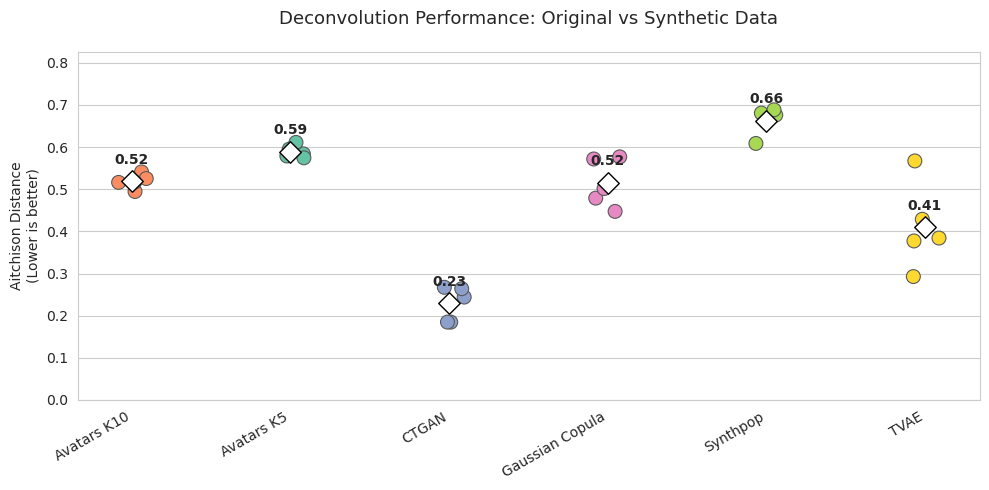

In [21]:
# 1. Chuyển dữ liệu dict của bạn thành DataFrame long-format
df_long = pd.DataFrame(Score_Result).T.melt(var_name='Method', value_name='Score')

# 2. Xác định thứ tự Method dựa trên điểm trung bình (Tăng dần)
method_order = df_long.groupby("Method")["Score"].mean().index

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

sns.stripplot(
    x='Method', 
    y='Score', 
    data=df_long, 
    order=method_order,
    size=10, 
    jitter=True, 
    palette='Set2', 
    edgecolor='gray', 
    linewidth=0.8,
    # alpha=0.6,
    hue='Method',
    legend=False
)

# Tính mean và vẽ diamond marker
means = df_long.groupby("Method")["Score"].mean().reindex(method_order)
offset = df_long['Score'].max() * 0.05 # Offset động dựa trên scale của dữ liệu

for i, mu in enumerate(means):
    plt.scatter(i, mu, marker='D', color='white', edgecolor='black', s=120, zorder=10)
    plt.text(i, mu + offset, f"{mu:.2f}", ha="center", va="bottom", fontsize=10, fontweight='bold')

plt.ylabel("Aitchison Distance\n(Lower is better)")
plt.xlabel("")
plt.xticks(rotation=30, ha='right')
plt.title("Deconvolution Performance: Original vs Synthetic Data", fontsize=13, pad=20)

# Giới hạn trục Y một chút để text label không bị cắt mất
plt.ylim(0, df_long['Score'].max() * 1.2)

plt.tight_layout()
plt.show()

In [26]:
import os
os.makedirs('AitchisonDistance', exist_ok = True)
pd.DataFrame(Score_Result).to_csv('AitchisonDistance/Score.csv', index = True)
pd.DataFrame(Distance_Result).to_csv('AitchisonDistance/Distance.csv', index = True)